In [1]:
from typing import List, Tuple, Union, Dict, Optional
import torch
from torch import Tensor
import numpy as np
from numpy import ndarray
from sympy import symbols, cos, sin, tan, Matrix, init_printing
import scipy
import matplotlib.pyplot as plt


In [2]:
to_numpy = lambda x : x.detach().numpy() if isinstance(x, Tensor) else x
set_t = {
    "dtype": torch.float32,
    "device": torch.device("cpu"),  # set to cpu if you don't have a graphics card
}
init_printing()


# Quadrotor 12 State Dynamic Linearization
One popular manner of stabilizing a nonlinear system is to linearize it about some equilibrium point and use LQR to produce a linear state-feedback controller that stabilizes the system to this equilibrium point. For a linear time-invariant (LTI) where the goal is to stabilize the system with an infinite time-horizon, the LQR problem has an exact solution given by the algebraic Ricatti equation (ARE).

Below, we symbolically define the parameters of our system. In the paper, we are only given the equations on how to update our system's positional and angular acceleration. However, if we want our system to be linearized in the form:
$$
\dot{x} = Ax + Bu
$$

The non-linear dynamics of our system are described as:
$$
\dot{x} = f(x) = \begin{bmatrix}v_x \\ v_y \\ v_z \\ a_x \\ a_y \\ a_z \\ p \\ q \\ r \\ \dot{p} \\ \dot{q} \\ \dot{r} \end{bmatrix} =
\begin{bmatrix}
v_x \\ v_y \\ v_z \\
\frac{1}{m}\begin{bmatrix}0\\0\\-mg\end{bmatrix} + \frac{1}{m}R\begin{bmatrix}0\\0\\\sum_{i=1}^4 F_i\end{bmatrix} \\
p \\ q\\ r \\
I^{-1}\left( \begin{bmatrix} L(F_2 - F_4) \\ L(F_3 - F_1) \\ M_1 - M_2 + M_3 - M_4 \end{bmatrix} - \begin{bmatrix}p\\q\\r\end{bmatrix}\times I\begin{bmatrix}p\\q\\r\end{bmatrix} \right)
\end{bmatrix}
$$
where
$$
\textit{ (state vector) }x := \begin{bmatrix}p_x & p_y & p_z & v_x & v_y & v_z & \phi & \theta & \psi & p & q & r \end{bmatrix}^\top
$$
$$
\textit{ (Inertia matrix) } I := \begin{bmatrix} I_x & 0 & 0 \\ 0 & I_y & 0 \\ 0 & 0 & I_z\end{bmatrix}
$$
$$
\textit{  (mass) } m
$$
$$
\textit{  (gravity) } g
$$
$$
\textit{  (length of arm from body to propeller) } L
$$
$$
\textit{ (force of each propeller) } F_i := k_f u_i^2
$$
$$
\textit{ (moment of each properller) } M_i := k_m u_i^2
$$
$$
\textit{ (position along each direction) } \begin{bmatrix}p_x & p_y & p_z\end{bmatrix}
$$
$$
\textit{ (velocity along each direction) } \begin{bmatrix}v_x & v_y & v_z\end{bmatrix}
$$
$$
\textit{ (acceleration along each direction) } \begin{bmatrix}a_x & a_y & a_z\end{bmatrix}
$$
$$
\textit{ (roll, pitch, and yaw) } \begin{bmatrix}\phi & \theta & \psi \end{bmatrix}
$$
$$
\textit{ (angular velocity) } \begin{bmatrix}p & q & r \end{bmatrix}
$$
$$
\textit{ (angular acceleration) } \begin{bmatrix}\dot{p} & \dot{q} & \dot{r} \end{bmatrix}
$$
$$
\textit{ (rotation matrix from body frame to world frame) } R
$$
Since we are using SymPy, and this module does not have a cross product operator, it is convenient to know that the following equivalance holds: $x\times y = \mathcal{S}(x)y$, where $\mathcal{S}$ is the skew matrix operator. In other words, we can replace the term:
$$
\begin{bmatrix}p\\q\\r\end{bmatrix}\times I\begin{bmatrix}p\\q\\r\end{bmatrix}
$$
with
$$
\begin{bmatrix}0&p&q\\-p&0&r\\-q&-r&0\end{bmatrix}I\begin{bmatrix}p\\q\\r\end{bmatrix}
$$
We want to linearize these dynamics such that it is in the form:
$$
\begin{bmatrix}v_x \\ v_y \\ v_z \\ a_x \\ a_y \\ a_z \\ p \\ q \\ r \\ \dot{p} \\ \dot{q} \\ \dot{r} \end{bmatrix} = A\begin{bmatrix}p_x\\p_y\\p_z\\v_x \\ v_y \\ v_z\\\phi\\\theta\\\psi \\ p \\ q \\ r \end{bmatrix} + Bu
$$
In shorthand, this is:
$$
\dot{x} = Ax + Bu
$$
This is the form that we want. In order to get $A$, we need to linearize the dynamics w.r.t. the state variables by getting the Jacobian of $\frac{\partial}{\partial x}f(x)$. Likewise, we get $B$ by linearizing the dynamics w.r.t. the control input by getting the Jacobian of $\frac{\partial}{\partial u}f(x)$.

In [3]:
# Define parameters, state variables and control input
m, g, km, kf = symbols('m g km kf')  # Position, velocity, control
phi, theta, psi = symbols('phi theta psi')
L = symbols('L')
p, q, r = symbols('p q r')
F1, F2, F3, F4 = symbols('F1 F2 F3 F4')
F = Matrix([F1, F2, F3, F4])
I1, I2, I3 = symbols('I1 I2 I3')
I = Matrix([[I1, 0, 0], [0, I2, 0], [0, 0, I3]])
I_inv = I.inv()
px, py, pz, vx, vy, vz, ax, ay, az = symbols('px py pz vx vy vz ax ay az')
u1, u2, u3, u4 = symbols('u1 u2 u3 u4')
u = Matrix([u1, u2, u3, u4])
F1 = u1**2 *kf
F2 = u2**2 *kf
F3 = u3**2 *kf
F4 = u4**2 *kf
M1 = u1**2 *km
M2 = u2**2 *km
M3 = u3**2 *km
M4 = u4**2 *km

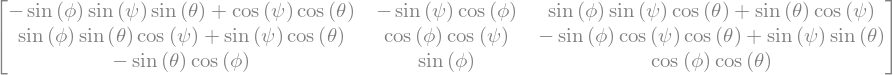

In [4]:
# the rotation matrix from the quadrotor's body frame to the world frame
R = Matrix([[cos(psi)*cos(theta) - sin(phi)*sin(psi)*sin(theta), -cos(phi)*sin(psi), cos(psi)*sin(theta) + cos(theta)*sin(phi)*sin(psi)],
                 [cos(theta)*sin(psi) + cos(psi)*sin(phi)*sin(theta), cos(phi)*cos(psi), sin(psi)*sin(theta) - cos(psi)*cos(theta)*sin(phi)],
                 [-cos(phi)*sin(theta), sin(phi), cos(phi)*cos(theta)]])
R

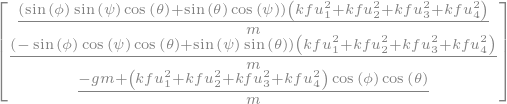

In [5]:
# the equations describing our positional acceleration
acc_matrix = (1/m) * ((Matrix([0, 0, -m*g]) + R@Matrix([0, 0, F1 + F2 + F3 + F4])))
acc_matrix

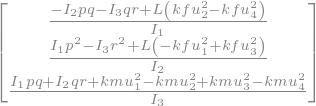

In [6]:
# the equations describing our angular acceleration
ang_matrix = I_inv @ (Matrix([[L*(F2-F4)], [L*(F3-F1)], [M1 - M2 + M3 - M4]]) - (Matrix([[0, p, q], [-p , 0, r], [-q, -r, 0]])@(I@Matrix([p, q, r]))))
ang_matrix

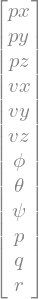

In [7]:
# the state vector
x = Matrix([px, py, pz, vx, vy, vz, phi, theta, psi, p, q, r])
x

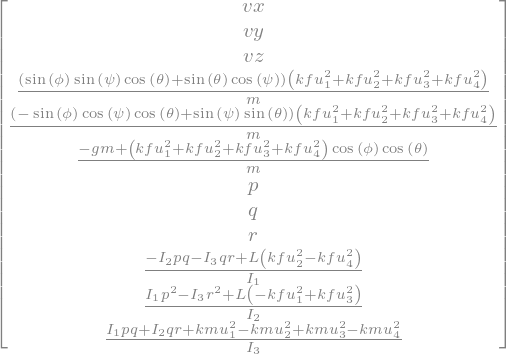

In [8]:
# derivative of the state vector ( same as nonlinear dynamics f(x) )
xdot = Matrix([vx, vy, vz, *acc_matrix[:, 0], p, q, r, *ang_matrix[:, 0]])
xdot

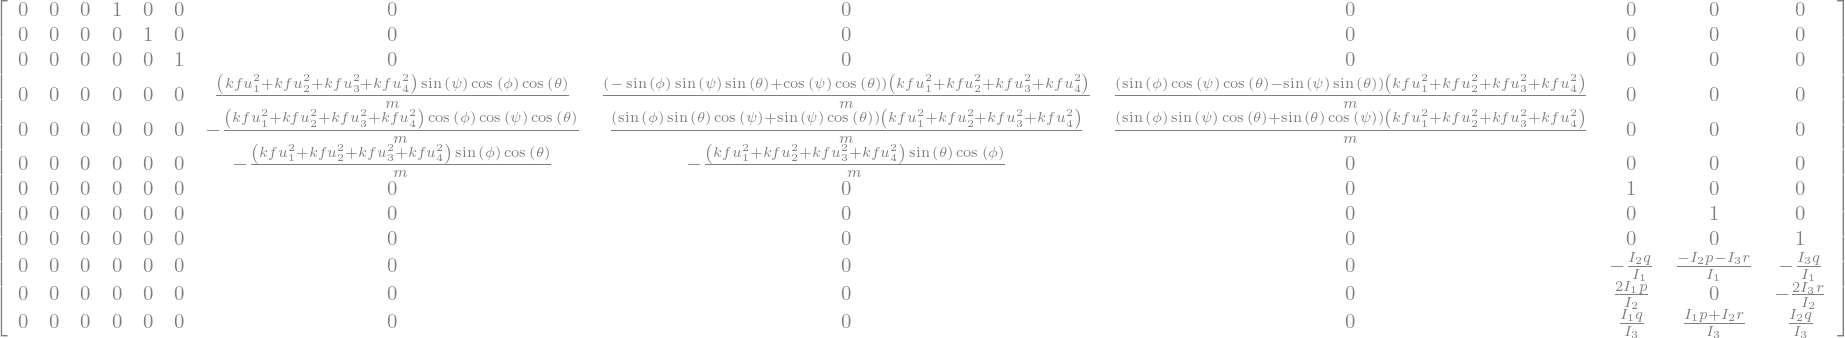

In [9]:
# linearize the dynamics w.r.t. x to get A
A_sym = xdot.jacobian(x)
A_sym

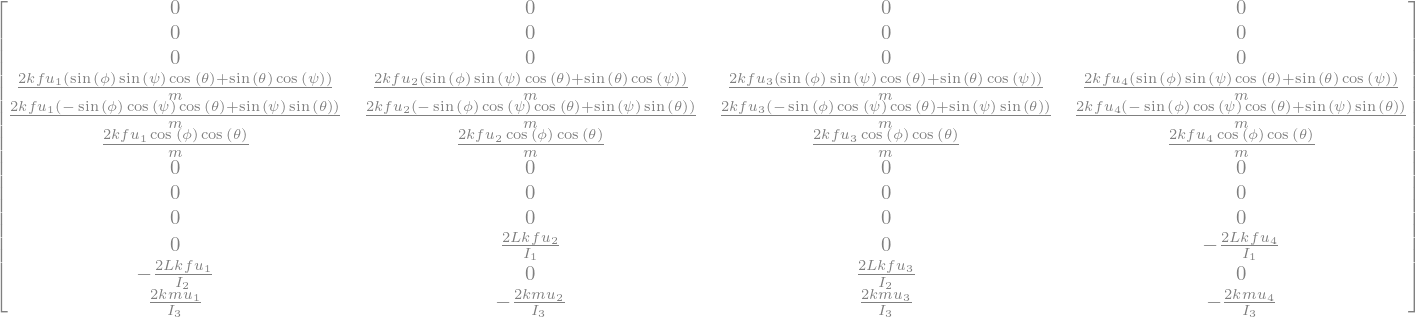

In [10]:
# lilnearize the dynamics w.r.t. xdot to get B
B_sym = xdot.jacobian(u)
B_sym

In [11]:
# Here we substitute in our symbolic values with our actual model parameters
values: Dict[symbols, float] = {
    L: 0.0397,
    I1: 2.3951e-5,
    I2: 2.3951e-5,
    I3: 3.2347e-5,
    px: 10, py: 10, pz: 10,
    vx: 0, vy: 0, vz: 0,
    p: 0., q: 0., r: 0.,
    phi: 0.0, theta: 0.0, psi: 0.0,
    g: -9.81,
    km: 7.94e-12,
    kf: 3.16e-10,
    u1: 25., u2: 25., u3: 25., u4: 25.,
    # u1: 0, u2: 0, u3: 0, u4: 0,
    F1: u1**2 *kf,
    F2: u2**2 *kf,
    F3: u3**2 *kf,
    F4: u4**2 *kf,
    m: 0.027
}

# Substitute values into the matrix
A_numeric = A_sym.subs(values)
B_numeric = B_sym.subs(values)


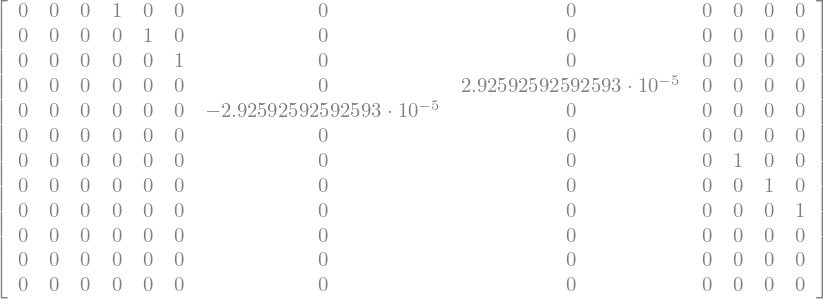

In [12]:
A_numeric

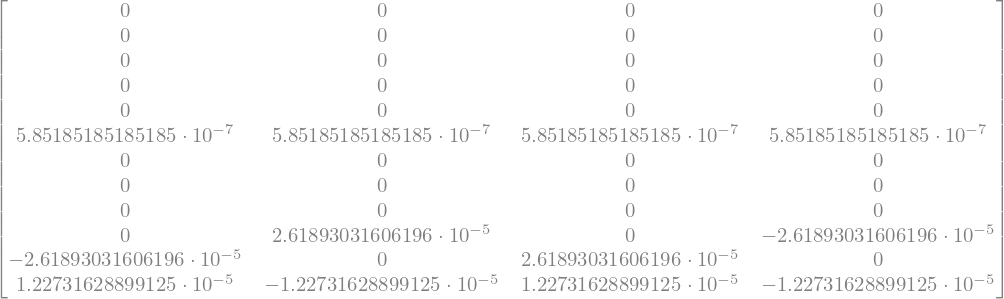

In [13]:
B_numeric

In [14]:
# Convert to a NumPy array
A_numpy = np.array(A_numeric.evalf(), dtype=np.float32)
B_numpy = np.array(B_numeric.evalf(), dtype=np.float32)

In [15]:
A_numpy

array([[ 0.000000e+00,  0.000000e+00,  0.000000e+00,  1.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00],
       [ 0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         1.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00],
       [ 0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  1.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00],
       [ 0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  2.925926e-05,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00],
       [ 0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00, -2.925926e-05,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000

In [16]:
B_numpy

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 5.8518521e-07,  5.8518521e-07,  5.8518521e-07,  5.8518521e-07],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  2.6189304e-05,  0.0000000e+00, -2.6189304e-05],
       [-2.6189304e-05,  0.0000000e+00,  2.6189304e-05,  0.0000000e+00],
       [ 1.2273163e-05, -1.2273163e-05,  1.2273163e-05, -1.2273163e-05]],
      dtype=float32)

In [17]:
def get_controllability_matrix(a: ndarray, b: ndarray) -> ndarray:
    """
    For an LTI system, return its controllability matrix.
    :param a: Linear state equations w.r.t. current state.
    :param b: Linear state equations w.r.t. input.
    :return:
    """
    n = a.shape[1]  # state dimension
    m = b.shape[1]  # control dimension

    # Use Cayley-Hamilton theorem to create a (n, nxm) controllability matrix whose rank tells us
    # how many states in the system are controllable.
    ctrl_matrix = b
    for i in range(1, n):
        ctrl_matrix = np.hstack((ctrl_matrix, np.linalg.matrix_power(a, i)@b))
    assert ctrl_matrix.shape == (n, n*m), f"Controllability matrix does not have the proper shape of ({(n, n*m)})"
    return ctrl_matrix

def controllability_rank(c: ndarray) -> int:
    """
    Gets the rank of the controllability matrix which tells us how many states in the system are controllable.
    :param c:   Controllability matrix
    :return:    Rank
    """
    rank_c = np.linalg.matrix_rank(c)
    return rank_c

def transform_system(A, B, T):

    A_transformed = T@A@T.inv()
    B_transformed = T@B

    return A_transformed, B_transformed

def get_controllable_subsystem(a: ndarray, b: ndarray, c: ndarray, rank_c: int) -> Tuple[ndarray, ndarray, ndarray]:
    """
    Performs Kalman decomposition to get the controllable subsystem as well as the linear transformation matrix T which puts the original system into this modal form.
    :param a:       Linear state dynamics w.r.t. current state.
    :param b:       Linear state dynamics w.r.t. input.
    :param c:       Controllability matrix.
    :param rank_c:  Rank of the controllability matrix.
    :return:
    """

    # Use QR decomposition to find an orthonormal basis for the controllable subspace
    Q, _ = np.linalg.qr(c)  # Q has orthonormal columns spanning the controllable subspace
    T = Q  # Transformation matrix

    # Transform A and B
    A_transformed = np.linalg.inv(T) @ a @ T
    B_transformed = np.linalg.inv(T) @ b
    print(f"New state system: ")
    print(f"Transformed A: \n{A_transformed}")
    print(f"Transformed B: \n{B_transformed}")
    # Identify which states are controllable
    controllable_states = np.where(np.sum(np.abs(T), axis=1) > 1e-6)[0]
    uncontrollable_states = np.setdiff1d(np.arange(A.shape[0]), controllable_states)
    print(f"Controllable states: {controllable_states}")
    print(f"Uncontrollable states: {uncontrollable_states}")

    # Extract controllable part
    A_c = A_transformed[:rank_c, :rank_c]
    B_c = B_transformed[:rank_c, :]

    return A_c, B_c, T

In [18]:
ctrl_matrix = get_controllability_matrix(A_numpy, B_numpy)
ctrl_rank = controllability_rank(ctrl_matrix)
can_ctrl = ctrl_rank >= A_numpy.shape[1]
print(f"Is this linear system controllable? {can_ctrl}")
print(f"Controllability matrix has a rank of {ctrl_rank} for a system with {A_numpy.shape[1]} state dimensions.")

# TODO: We don't need to perform the Kalman decomposition as we can now see that the system is controllable.
# # get the controllable subsystem:
# A_c, B_c, T = get_controllable_subsystem(A_numpy, B_numpy, ctrl_matrix, ctrl_rank)

Is this linear system controllable? True
Controllability matrix has a rank of 12 for a system with 12 state dimensions.


At this point, we have the equations that we need in order to produce a linear state-feedback controller for our controllable subsystem in the form:
$$
u = -Kx
$$
Finding this controller involves solving the LQR (Linear Quadratic Regular) control optimal problem:
$$
\min_u J(x, u) := \min_u \int_{t=0}^{\infty} x^\top Qx + u^\top R u \; dt
$$
where $Q \in \mathbb{R}^{n\times n}$ and $R \in \mathbb{R}^{m\times m}$. We also have that $Q$ and $R$ are both symmetric. $Q$ is positive semi-definite and $R$ is positive definite.

Luckily, this optimization problem has a closed-form solution given by the algebraic Riccati equation, and scipy has a method that can solve for this solution.

In [19]:
Q = np.eye(A_numpy.shape[1])
R = np.eye(B_numpy.shape[1])
S = scipy.linalg.solve_continuous_are(A_numpy, B_numpy, Q, R)
K = -np.linalg.solve(R, B_numpy.T @ S)
print(f"K (shape : {K.shape})\n{K}")

K (shape : (4, 12))
[[ 7.07106781e-01  2.50774872e-15 -5.00000000e-01  3.40076924e+02
   1.18763541e-12 -6.53617186e+02 -9.26370536e-15  2.39276905e+00
  -5.00000000e-01 -1.55800441e-12  3.02266212e+02 -1.42723151e+02]
 [ 1.20686586e-14  7.07106781e-01 -5.00000000e-01  3.34244928e-12
   3.40076924e+02 -6.53617186e+02 -2.39276905e+00  1.17588942e-14
   5.00000000e-01 -3.02266212e+02 -1.82633696e-13  1.42723151e+02]
 [-7.07106781e-01  7.80687837e-15 -5.00000000e-01 -3.40076924e+02
   3.35589437e-12 -6.53617186e+02 -2.04836976e-14 -2.39276905e+00
  -5.00000000e-01 -2.02119027e-12 -3.02266212e+02 -1.42723151e+02]
 [-8.39251057e-15 -7.07106781e-01 -5.00000000e-01 -2.01646647e-12
  -3.40076924e+02 -6.53617186e+02  2.39276905e+00 -5.98429971e-15
   5.00000000e-01  3.02266212e+02  2.80552164e-13  1.42723151e+02]]


The linearized controller $u = -Kx$ is for our state system after we have put it into Kalman decomposition form. In particular, it is better to denote our state system after we perform the Kalman decomposition as:
$$
\dot{\bar{x}} = \bar{A}\bar{x} + \bar{B}u
$$
Where our controller is for this system, such that $u = -K\bar{x}$. 

Therefore, we can bring our controller back into our original system as:
$$
\dot{x} = T^{-1}\bar{A}Tx + T^{-1}\bar{B}KTx
$$

We can double check the controllability using the control library

# Next Steps

1) We want to be able to concretely say which states are controllable. It does not matter that 7 states are controllable we cannot control for example, the altitude of the quadrotor. We need to answer this question.
2) $K$ is our linear state-feedback controller. Our controller can be written as $u = -Kx$. In other words, based on our current state $x$, $u$ will give us the control input we should use to move towards equilibrium. **However**, we only have $K$ for the 7 state sub-system. Can we write what our control would look like for our original 12 state-system? Is it necessary to rewrite K? 
3) Once we know which states are controllable, and we are satisfied with our controller, we should create some plot or visualization to quickly confirm that this controller can stabilize our system for points *near* the equilibrium point. 

# Visualization

In [20]:
def compute_lqr(A, B):
    """
    Computes the LQR controller about some equilibrium point.
    The solution entails a controller in linear feedback form u=Kx
    as well a Lyapunov function in quadratic form V=x^TSx.
    :param pendulum_continuous: Continuous pendulum model
    :return:                    Controller, Lyapunov function

    get_controllable_subsystem(A, B, ctrl_matrix, ctrl_rank)
    """
    # check to see that the system is controllable
    ctrl_matrix = get_controllability_matrix(A, B)
    ctrl_rank = controllability_rank(ctrl_matrix)
    can_ctrl = ctrl_rank >= A_numpy.shape[1]
    assert can_ctrl, f"This system is not controllable."

    Q = np.eye(A.shape[1])
    R = np.eye(B.shape[1]) * 100
    S = scipy.linalg.solve_continuous_are(A, B, Q, R)
    K = -np.linalg.solve(R, B.T @ S)

    return K, S


This cell is for plotting the Lyapunov function for only the first two states.

K shape: torch.Size([4, 12])


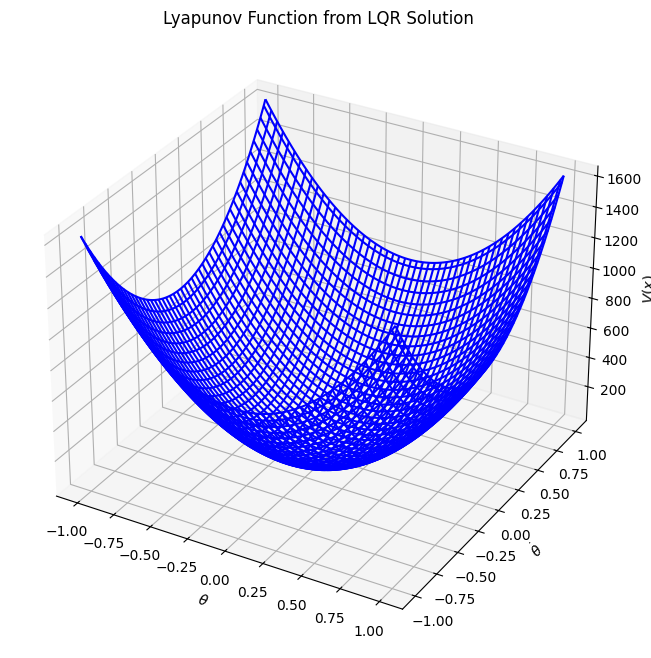

In [21]:
K, S = compute_lqr(A_numpy, B_numpy)
# convert to Tensors
K = torch.from_numpy(K).to(**set_t)  # linear feedback controller
S = torch.from_numpy(S).to(**set_t)  # quadratic Lyapunov function
print(f"K shape: {K.shape}")

# plot the output of the Lyapunov function for these samples
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
x_np = np.linspace(-1, 1, 100)
y_np = np.linspace(-1, 1, 100)
x_np, y_np = np.meshgrid(x_np, y_np)
lqr_lya = lambda x: np.sum(x * (x @ to_numpy(S)), axis=1)  # applies Lyapunov function to state inputs
x_orig = np.concatenate((x_np.ravel().reshape(-1, 1), y_np.ravel().reshape(-1, 1)), axis=1)
V_np = lqr_lya(np.concatenate((x_orig, np.zeros((x_orig.shape[0], A_numpy.shape[1] - 2))), axis=1))
V_np = V_np.reshape(x_np.shape)
ax.plot_wireframe(x_np, y_np, V_np, color='b')
ax.set_title("Lyapunov Function from LQR Solution")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\dot{\theta}$")
ax.set_zlabel(r"$V(x)$")
plt.show()

This cell plots the state dynamics of the first two states.

In [22]:
K, S = compute_lqr(final_a_matrix_numpy, final_b_matrix_numpy)
# convert to Tensors
K = torch.from_numpy(K).to(**set_t)  # linear feedback controller
S = torch.from_numpy(S).to(**set_t)  # quadratic Lyapunov function
# x = (torch.rand((100, 2), **set_t) - 0.5) * 2  # create a bunch of state samples near the origin to stabilize
# x = torch.cat([x, torch.zeros((1, 2), **set_t)], dim=0)  # make sure to include the equilibrium
# V = torch.sum(x * (x @ S), axis=1, keepdim=True)
print(f"K shape: {K.shape}")

# plot the output of the Lyapunov function for these samples
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
x_np = np.linspace(-1, 1, 100)
y_np = np.linspace(-1, 1, 100)
x_np, y_np = np.meshgrid(x_np, y_np)
lqr_lya = lambda x: np.sum(x * (x @ to_numpy(S)), axis=1)  # applies Lyapunov function to state inputs
orig_x = np.concatenate((x_np.ravel().reshape(-1, 1), y_np.ravel().reshape(-1, 1)), axis=1)
print(f"orig_x has shape {orig_x.shape}")
V_np = lqr_lya(np.concatenate([orig_x, np.zeros((orig_x.shape[0], 5))], axis=1))
V_np = V_np.reshape(x_np.shape)
ax.plot_wireframe(x_np, y_np, V_np, color='b')
ax.set_title("Lyapunov Function from LQR Solution")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\dot{\theta}$")
ax.set_zlabel(r"$V(x)$")
# if save: plt.savefig(save_path + "lqr_quadratic_lyapunov_function.png")
# plt.show() if show else plt.close()

NameError: name 'final_a_matrix_numpy' is not defined